# Policy Gradient (REINFORCE) + Deep Q-Learning
### Environment: `LunarLander-v3`
**Continuous state space (8D), Discrete action space (4 actions)**

LunarLander is ideal for comparing Policy Gradient vs Deep Q-Learning:
- State: position (x,y), velocity (vx,vy), angle, angular velocity, leg contact booleans
- Actions: do nothing, fire left thruster, fire main engine, fire right thruster
- Reward: landing reward +100-140, crash -100, leg contact +10 each, fuel penalty

Based on REINFORCE method from *Deep Reinforcement Learning Hands-On* by Maxim Lapan.

## 1. Import Libraries

In [1]:
import gymnasium as gym
import numpy as np
import random
from collections import deque
from IPython.display import clear_output
import time
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical

print("PyTorch version:", torch.__version__)
print("Gymnasium version:", gym.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cpu
Gymnasium version: 1.2.3
Using device: cpu


## 2. Initialize Environment

> **Why LunarLander-v3?**  
> FrozenLake has a *discrete* state space (16 tiles), making it easy to use a Q-table directly.  
> LunarLander has a **continuous** 8-dimensional state vector — you cannot make a Q-table for it,  
> so a neural network function approximator (DQN) or a Policy Network (REINFORCE) is required.  
> This makes it an ideal benchmark to compare the two approaches.

In [3]:
env_name = "LunarLander-v3"

# Use 'rgb_array' for headless training (no GUI window needed in notebooks)
# Switch to 'human' if you want a popup render window
render_mode_name = "rgb_array"
env = gym.make(env_name, render_mode=render_mode_name)

print("Environment:", env_name)
print("Observation Space:", env.observation_space)
print("  Shape:", env.observation_space.shape)
print("  Low: ", env.observation_space.low)
print("  High:", env.observation_space.high)
print()
print("Action Space:", env.action_space)
print("  Type:", type(env.action_space))
print("  n   :", env.action_space.n)
print()
print("Action meanings: 0=do nothing, 1=fire left, 2=fire main, 3=fire right")

Environment: LunarLander-v3
Observation Space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
  Shape: (8,)
  Low:  [ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ]
  High: [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ]

Action Space: Discrete(4)
  Type: <class 'gymnasium.spaces.discrete.Discrete'>
  n   : 4

Action meanings: 0=do nothing, 1=fire left, 2=fire main, 3=fire right


c:\Users\Reece S\Documents\GitHub\capstone4ds\.dqn_pong_env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 3. Shared Network Architectures

In [4]:
class DeepQNetwork(nn.Module):
    """Value network: maps state -> Q-value per action."""
    def __init__(self, input_size, output_size, hidden_size=128):
        super(DeepQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.network(x)


class PolicyNetwork(nn.Module):
    """Policy network: maps state -> action probability distribution (softmax)."""
    def __init__(self, input_size, output_size, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
            # NOTE: No softmax here — Categorical handles it via logits
        )

    def forward(self, x):
        return self.network(x)

    def get_action_and_log_prob(self, state_tensor):
        """Sample an action and return both the action and its log probability."""
        logits = self.forward(state_tensor)
        dist = Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob


print("DeepQNetwork and PolicyNetwork defined.")

DeepQNetwork and PolicyNetwork defined.


## 4. Base Agent

In [5]:
class Agent:
    """
    Base agent. Handles discrete vs. continuous action space detection.
    All specialised agents inherit from this.
    """
    def __init__(self, env):
        self.is_discrete = isinstance(env.action_space, gym.spaces.Discrete)
        print("Is Discrete Action Space?", self.is_discrete)

        if self.is_discrete:
            self.action_size = env.action_space.n
            print("Action size:", self.action_size)
        else:
            self.action_space_low  = env.action_space.low
            self.action_space_high = env.action_space.high
            self.action_shape      = env.action_space.shape
            print("Action range:", self.action_space_low, "->", self.action_space_high)

    def get_action(self, observation):
        """Uniformly random action — used as fallback / exploration baseline."""
        if self.is_discrete:
            return random.choice(range(self.action_size))
        return np.random.uniform(self.action_space_low, self.action_space_high, self.action_shape)


print("Base Agent defined.")

Base Agent defined.


## 5. Deep Q-Learning Agent (DQN)

Adapted from `QLearning_Deep.ipynb` with:
- Experience replay buffer for more stable training
- A separate **target network** (frozen copy) to stabilise TD targets
- Continuous state support via `process_state()`

In [6]:
class ReplayBuffer:
    """Fixed-size circular buffer for experience replay."""
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)),
            torch.LongTensor(actions),
            torch.FloatTensor(rewards),
            torch.FloatTensor(np.array(next_states)),
            torch.FloatTensor(dones)
        )

    def __len__(self):
        return len(self.buffer)


class DeepQAgent(Agent):
    """
    DQN Agent with:
      - Experience replay
      - Target network (updated every `target_update` episodes)
      - Epsilon-greedy exploration with exponential decay
    """
    def __init__(self, env,
                 discount_rate=0.99,
                 learning_rate=1e-3,
                 epsilon=1.0,
                 epsilon_decay=0.995,
                 epsilon_min=0.01,
                 batch_size=64,
                 replay_capacity=10_000,
                 target_update=10):
        super().__init__(env)

        self.discount_rate = discount_rate
        self.learning_rate = learning_rate
        self.eps           = epsilon
        self.eps_decay     = epsilon_decay
        self.eps_min       = epsilon_min
        self.batch_size    = batch_size
        self.target_update = target_update
        self.update_count  = 0

        # Continuous state detection
        if hasattr(env.observation_space, 'n'):
            self.state_size    = env.observation_space.n
            self.discrete_state = True
        else:
            self.state_size    = env.observation_space.shape[0]
            self.discrete_state = False

        # Online network + frozen target network
        self.model        = DeepQNetwork(self.state_size, self.action_size).to(device)
        self.target_model = DeepQNetwork(self.state_size, self.action_size).to(device)
        self.target_model.load_state_dict(self.model.state_dict())
        self.target_model.eval()

        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.loss_fn   = nn.SmoothL1Loss()   # Huber loss — more robust than MSE
        self.memory    = ReplayBuffer(replay_capacity)

        # Metrics tracking
        self.last_loss    = None
        self.last_td_error = None

        print(f"DeepQAgent ready | state_size={self.state_size} | action_size={self.action_size}")

    def process_state(self, state):
        """Convert raw env state into a FloatTensor (one-hot if discrete)."""
        if self.discrete_state:
            v = np.zeros(self.state_size, dtype=np.float32)
            v[state] = 1.0
            return torch.FloatTensor(v).to(device)
        return torch.FloatTensor(state).to(device)

    def get_action(self, observation):
        if random.random() < self.eps:
            return super().get_action(observation)
        state_t = self.process_state(observation).unsqueeze(0)
        with torch.no_grad():
            q_values = self.model(state_t)
        return torch.argmax(q_values).item()

    def remember(self, state, action, reward, next_state, done):
        """Push a transition into the replay buffer."""
        s  = state  if not self.discrete_state else self._one_hot(state)
        ns = next_state if not self.discrete_state else self._one_hot(next_state)
        self.memory.push(s, action, reward, ns, float(done))

    def _one_hot(self, state):
        v = np.zeros(self.state_size, dtype=np.float32)
        v[state] = 1.0
        return v

    def train(self):
        """Sample a mini-batch and perform one gradient update."""
        if len(self.memory) < self.batch_size:
            return  # not enough samples yet

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states      = states.to(device)
        actions     = actions.to(device)
        rewards     = rewards.to(device)
        next_states = next_states.to(device)
        dones       = dones.to(device)

        # Current Q(s,a)
        q_values = self.model(states)
        q_value  = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        # Target Q using frozen target network
        with torch.no_grad():
            next_q     = self.target_model(next_states).max(1)[0]
            q_target   = rewards + self.discount_rate * next_q * (1 - dones)

        loss = self.loss_fn(q_value, q_target)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=10)  # gradient clipping
        self.optimizer.step()

        # Store metrics
        with torch.no_grad():
            self.last_loss     = loss.item()
            self.last_td_error = (q_target - q_value).abs().mean().item()

    def end_episode(self):
        """Call once per episode: epsilon decay + periodic target network sync."""
        self.eps = max(self.eps_min, self.eps * self.eps_decay)
        self.update_count += 1
        if self.update_count % self.target_update == 0:
            self.target_model.load_state_dict(self.model.state_dict())


print("DeepQAgent defined.")

DeepQAgent defined.


## 6. Policy Gradient Agent (REINFORCE)

REINFORCE (Monte Carlo Policy Gradient) — from *Deep RL Hands-On* by Maxim Lapan, Ch. 11.

**Key idea:** Instead of learning *values*, directly optimise the policy π(a|s; θ) by maximising  
the expected return. The gradient estimator (policy gradient theorem) is:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t \right]$$

where $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ is the discounted return from step $t$.

**Implementation notes:**
- The full episode trajectory is collected *before* any weight update (Monte Carlo)
- Returns are normalised per episode to reduce variance (baseline trick)
- Loss = $-\sum_t \log \pi(a_t|s_t) \cdot G_t$ (negative because we do gradient *ascent*)

In [7]:
class PolicyGradientAgent(Agent):
    """
    REINFORCE (Monte Carlo Policy Gradient) agent.

    Unlike DQN, this agent:
      - Does NOT use a replay buffer (on-policy: data must come from current policy)
      - Collects a FULL episode before updating weights
      - Directly optimises the policy network π(a|s)
      - Uses no epsilon-greedy — exploration comes from the stochastic policy itself

    Reference: Lapan, M. (2020). Deep Reinforcement Learning Hands-On, Ch. 11.
    """
    def __init__(self, env,
                 discount_rate=0.99,
                 learning_rate=1e-3,
                 entropy_beta=0.01):
        """
        Args:
            env:           Gymnasium environment
            discount_rate: γ — future reward discount factor
            learning_rate: Adam optimizer learning rate
            entropy_beta:  Coefficient for entropy bonus (encourages exploration).
                           Set to 0.0 to disable. Lapan recommends 0.01.
        """
        super().__init__(env)

        self.discount_rate = discount_rate
        self.learning_rate = learning_rate
        self.entropy_beta  = entropy_beta

        # Detect state size (continuous vs discrete)
        if hasattr(env.observation_space, 'n'):
            self.state_size    = env.observation_space.n
            self.discrete_state = True
        else:
            self.state_size    = env.observation_space.shape[0]
            self.discrete_state = False

        # Policy network
        self.policy    = PolicyNetwork(self.state_size, self.action_size).to(device)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=self.learning_rate)

        # Episode trajectory storage (cleared each episode)
        self._log_probs = []   # log π(a_t | s_t) for each step
        self._rewards   = []   # r_t for each step
        self._entropies = []   # H[π(·|s_t)] for entropy regularisation

        # Metrics
        self.last_loss           = None
        self.last_policy_loss    = None
        self.last_entropy_loss   = None
        self.last_mean_return    = None

        print(f"PolicyGradientAgent ready | state_size={self.state_size} | action_size={self.action_size}")
        print(f"  discount_rate={discount_rate} | lr={learning_rate} | entropy_beta={entropy_beta}")

    def process_state(self, state):
        """Convert raw env state into a FloatTensor."""
        if self.discrete_state:
            v = np.zeros(self.state_size, dtype=np.float32)
            v[state] = 1.0
            return torch.FloatTensor(v).to(device)
        return torch.FloatTensor(state).to(device)

    def get_action(self, observation):
        """
        Sample action from the current policy distribution.
        Stores log_prob and entropy for the upcoming train() call.
        """
        state_t = self.process_state(observation)
        logits  = self.policy(state_t)
        dist    = Categorical(logits=logits)

        action   = dist.sample()
        log_prob = dist.log_prob(action)
        entropy  = dist.entropy()

        # Stash for train() — will be consumed at episode end
        self._log_probs.append(log_prob)
        self._entropies.append(entropy)

        return action.item()

    def store_reward(self, reward):
        """Call after each env.step() to record the received reward."""
        self._rewards.append(reward)

    def train(self):
        """
        Compute discounted returns G_t for all steps, then perform ONE
        gradient update on the policy network.

        Must be called ONCE per episode (after the episode ends).
        Clears the internal trajectory buffer automatically.

        Returns:
            total_loss (float): The total scalar loss for logging.
        """
        if not self._rewards:
            return None

        # ── Step 1: Compute discounted returns G_t ──────────────────────
        # Work backwards: G_T = r_T, G_{t} = r_t + γ·G_{t+1}
        returns = []
        G = 0.0
        for r in reversed(self._rewards):
            G = r + self.discount_rate * G
            returns.insert(0, G)

        returns_t = torch.FloatTensor(returns).to(device)

        # ── Step 2: Normalise returns (baseline / variance reduction) ───
        # Subtracting the mean reduces variance without introducing bias.
        # This is one of the simplest baselines from Lapan Ch. 11.
        if len(returns_t) > 1:
            returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        # ── Step 3: Policy gradient loss ────────────────────────────────
        log_probs = torch.stack(self._log_probs)   # shape: [T]
        entropies = torch.stack(self._entropies)   # shape: [T]

        # Negative sign: we want to MAXIMISE E[G_t · log π], so MINIMISE its negative
        policy_loss  = -(log_probs * returns_t).mean()

        # Entropy bonus: encourages exploration by penalising low-entropy policies
        entropy_loss = -self.entropy_beta * entropies.mean()

        total_loss = policy_loss + entropy_loss

        # ── Step 4: Backpropagation ──────────────────────────────────────
        self.optimizer.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=1.0)
        self.optimizer.step()

        # ── Step 5: Save metrics & reset buffer ─────────────────────────
        self.last_loss         = total_loss.item()
        self.last_policy_loss  = policy_loss.item()
        self.last_entropy_loss = entropy_loss.item()
        self.last_mean_return  = float(np.mean(returns))   # pre-normalised mean

        self._log_probs.clear()
        self._rewards.clear()
        self._entropies.clear()

        return self.last_loss


print("PolicyGradientAgent defined.")

PolicyGradientAgent defined.


## 7. Training Metrics Tracker

A lightweight helper to record, print, and plot training statistics.

In [8]:
class TrainingMetrics:
    """
    Tracks and displays per-episode training statistics.

    Stored per episode:
      - episode_rewards: total undiscounted reward
      - episode_lengths: number of steps taken
      - losses:          scalar loss (if available)
      - td_errors:       mean |TD error| (DQN only)
      - epsilons:        epsilon value at end of episode (DQN only)
    """
    def __init__(self, window=50):
        self.window           = window
        self.episode_rewards  = []
        self.episode_lengths  = []
        self.losses           = []
        self.td_errors        = []
        self.epsilons         = []

    def record(self, episode_reward, episode_length, loss=None, td_error=None, epsilon=None):
        self.episode_rewards.append(episode_reward)
        self.episode_lengths.append(episode_length)
        self.losses.append(loss)
        self.td_errors.append(td_error)
        self.epsilons.append(epsilon)

    def rolling_avg(self, data, n=None):
        n = n or self.window
        valid = [x for x in data[-n:] if x is not None]
        return np.mean(valid) if valid else None

    def print_episode(self, episode, total_episodes, agent_name="Agent"):
        ep       = episode + 1
        r        = self.episode_rewards[-1]
        r_avg    = self.rolling_avg(self.episode_rewards)
        steps    = self.episode_lengths[-1]
        loss     = self.losses[-1]
        td_err   = self.td_errors[-1]
        eps      = self.epsilons[-1]

        bar_len  = 20
        filled   = int(bar_len * ep / total_episodes)
        bar      = '█' * filled + '░' * (bar_len - filled)

        print(f"[{bar}] Ep {ep:4d}/{total_episodes}  |  Agent: {agent_name}")
        print(f"  Reward:    {r:8.2f}   |  Avg-{self.window}: {r_avg:8.2f}")
        print(f"  Steps:     {steps:5d}")
        if loss is not None:
            print(f"  Loss:      {loss:10.5f}")
        if td_err is not None:
            print(f"  TD Error:  {td_err:10.5f}")
        if eps is not None:
            print(f"  Epsilon:   {eps:8.4f}")

    def plot(self, title="Training Metrics"):
        """Plot reward curve and loss curve side by side."""
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(title, fontsize=14)

        eps_range = range(1, len(self.episode_rewards) + 1)

        # Reward
        axes[0].plot(eps_range, self.episode_rewards, alpha=0.4, color='steelblue', label='Episode Reward')
        if len(self.episode_rewards) >= self.window:
            rolling = np.convolve(self.episode_rewards,
                                   np.ones(self.window)/self.window, mode='valid')
            axes[0].plot(range(self.window, len(self.episode_rewards)+1),
                         rolling, color='navy', linewidth=2,
                         label=f'{self.window}-ep Rolling Avg')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylabel('Total Reward')
        axes[0].set_title('Episode Reward')
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        # Loss
        valid_losses = [(i+1, l) for i, l in enumerate(self.losses) if l is not None]
        if valid_losses:
            lx, ly = zip(*valid_losses)
            axes[1].plot(lx, ly, color='tomato', alpha=0.6, label='Loss')
            axes[1].set_xlabel('Episode')
            axes[1].set_ylabel('Loss')
            axes[1].set_title('Training Loss')
            axes[1].legend()
            axes[1].grid(alpha=0.3)
        else:
            axes[1].text(0.5, 0.5, 'No loss data', ha='center', va='center',
                         transform=axes[1].transAxes)

        plt.tight_layout()
        plt.show()


print("TrainingMetrics defined.")

TrainingMetrics defined.


## 8. Training Loop — DQN on LunarLander

> DQN improvement suggestions over the original notebooks:
> - **`remember()` + `train()`** are now separated — `remember` buffers the transition, `train` samples a mini-batch
> - **`end_episode()`** decays epsilon and optionally syncs the target network
> - **`TrainingMetrics`** records loss, TD error, epsilon, reward, and episode length
> - Loss is now **Huber / SmoothL1** instead of MSE — less sensitive to outlier TD errors
> - Gradient norms are clipped to prevent exploding gradients

In [9]:
NUM_EPISODES_DQN = 500

dqn_agent   = DeepQAgent(env)
dqn_metrics = TrainingMetrics(window=50)

for ep in range(NUM_EPISODES_DQN):
    observation, info = env.reset()
    done              = False
    episode_reward    = 0
    episode_steps     = 0

    while not done:
        action = dqn_agent.get_action(observation)

        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Buffer this transition
        dqn_agent.remember(observation, action, reward, next_observation, done)

        # Sample from replay buffer and update the network
        dqn_agent.train()

        observation    = next_observation
        episode_reward += reward
        episode_steps  += 1

    # End-of-episode bookkeeping (epsilon decay, target network sync)
    dqn_agent.end_episode()

    dqn_metrics.record(
        episode_reward = episode_reward,
        episode_length = episode_steps,
        loss           = dqn_agent.last_loss,
        td_error       = dqn_agent.last_td_error,
        epsilon        = dqn_agent.eps
    )

    clear_output(wait=True)
    dqn_metrics.print_episode(ep, NUM_EPISODES_DQN, agent_name="DQN")

print("\nDQN Training complete.")

[████████████████████] Ep  500/500  |  Agent: DQN
  Reward:      162.33   |  Avg-50:   127.71
  Steps:      1000
  Loss:         0.13675
  TD Error:     0.32178
  Epsilon:     0.0816

DQN Training complete.


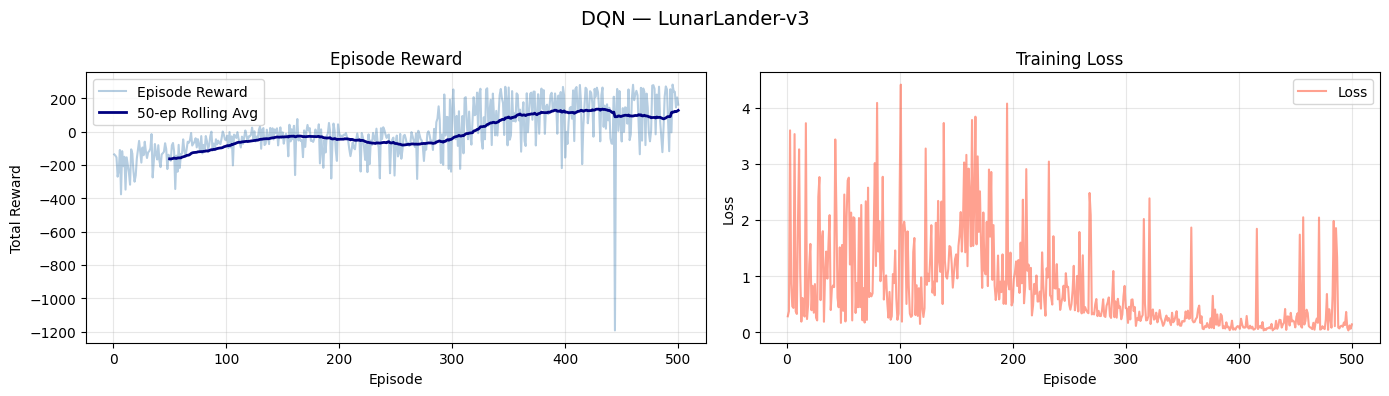

In [10]:
dqn_metrics.plot(title="DQN — LunarLander-v3")

## 9. Training Loop — REINFORCE (Policy Gradient) on LunarLander

> Key differences from the DQN loop:
> - **`store_reward()`** is called every step (instead of `remember`)
> - **`train()`** is called **once per episode** (Monte Carlo — needs the full trajectory)
> - There is no epsilon, replay buffer, or target network
> - Loss is the negative policy gradient objective (lower = better policy)

In [16]:
NUM_EPISODES_PG = 1000

pg_agent   = PolicyGradientAgent(env)
pg_metrics = TrainingMetrics(window=50)

for ep in range(NUM_EPISODES_PG):
    observation, info = env.reset()
    done              = False
    episode_reward    = 0
    episode_steps     = 0

    while not done:
        # get_action internally stores log_prob & entropy for this step
        action = pg_agent.get_action(observation)

        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Record the reward received
        pg_agent.store_reward(reward)

        observation    = next_observation
        episode_reward += reward
        episode_steps  += 1

    # Full-episode gradient update — this is the REINFORCE update
    pg_agent.train()

    pg_metrics.record(
        episode_reward = episode_reward,
        episode_length = episode_steps,
        loss           = pg_agent.last_loss,
        td_error       = None,    # N/A for policy gradient
        epsilon        = None     # N/A — exploration via stochastic policy
    )

    clear_output(wait=True)
    pg_metrics.print_episode(ep, NUM_EPISODES_PG, agent_name="REINFORCE")

print("\nPolicy Gradient Training complete.")

[████████████████████] Ep 1000/1000  |  Agent: REINFORCE
  Reward:       23.34   |  Avg-50:     3.96
  Steps:      1000
  Loss:         0.00362

Policy Gradient Training complete.


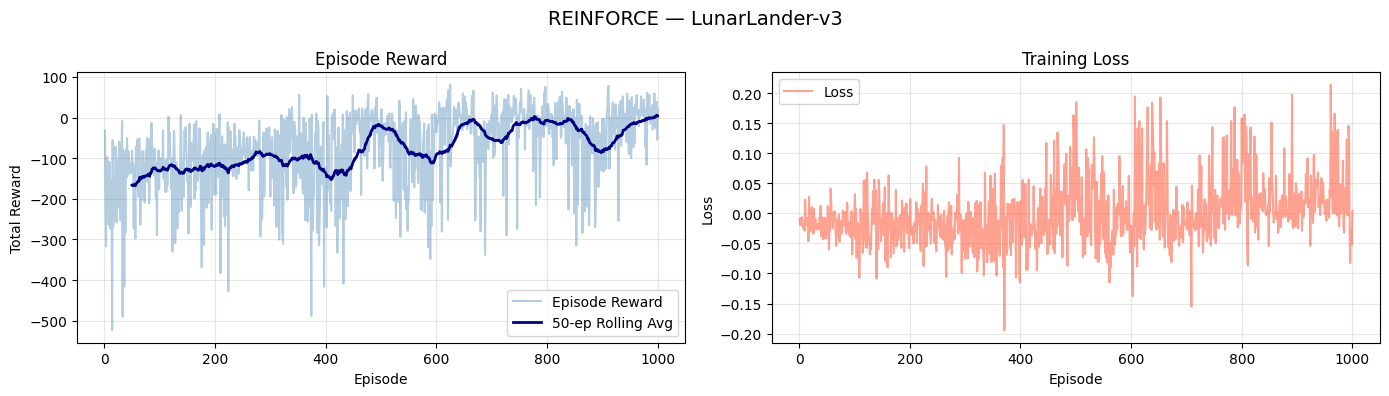

In [17]:
pg_metrics.plot(title="REINFORCE — LunarLander-v3")

## 10. Side-by-Side Comparison

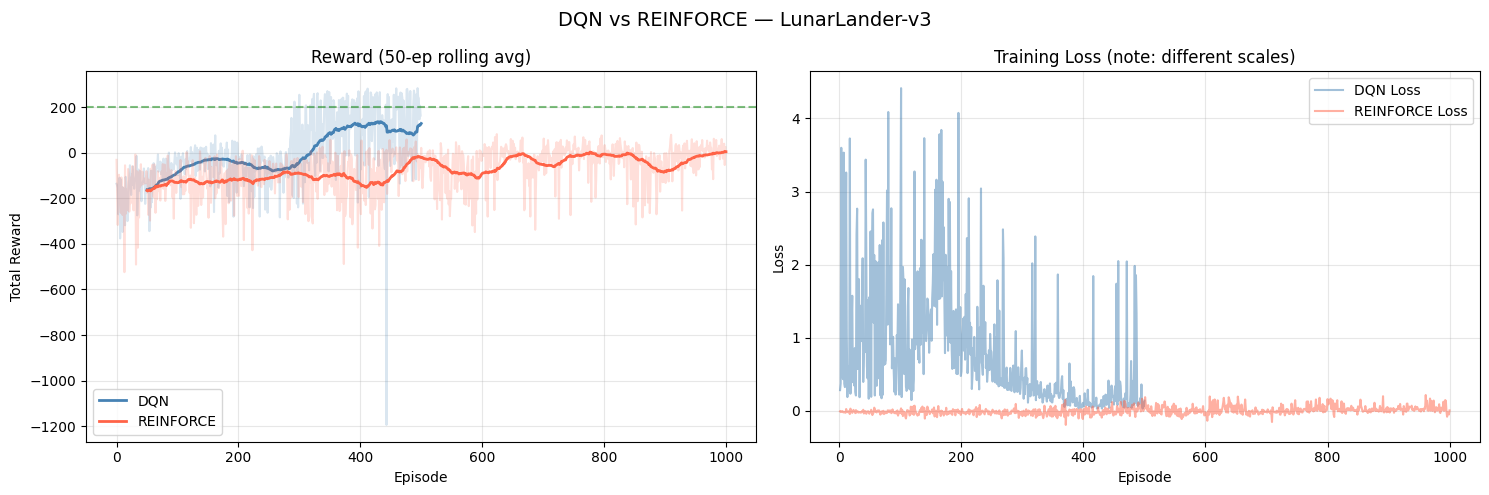

Metric                           DQN    REINFORCE
--------------------------------------------------
Avg Reward (last 50)          127.71         3.96
Avg Loss (last 50)           0.36802      0.03437
Avg Steps (last 50)            408.1        688.8


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("DQN vs REINFORCE — LunarLander-v3", fontsize=14)
WINDOW = 50

for ax, metrics, label, color in [
    (axes[0], dqn_metrics, "DQN",       "steelblue"),
    (axes[0], pg_metrics,  "REINFORCE", "tomato"),
]:
    ax.plot(metrics.episode_rewards, alpha=0.2, color=color)
    if len(metrics.episode_rewards) >= WINDOW:
        rolling = np.convolve(metrics.episode_rewards,
                               np.ones(WINDOW)/WINDOW, mode='valid')
        ax.plot(range(WINDOW, len(metrics.episode_rewards)+1),
                rolling, color=color, linewidth=2, label=label)

axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title(f'Reward ({WINDOW}-ep rolling avg)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].axhline(200, color='green', linestyle='--', alpha=0.5, label='Solved threshold')

# Loss comparison
for ax, metrics, label, color in [
    (axes[1], dqn_metrics, "DQN Loss",         "steelblue"),
    (axes[1], pg_metrics,  "REINFORCE Loss",   "tomato"),
]:
    valid = [(i+1, l) for i, l in enumerate(metrics.losses) if l is not None]
    if valid:
        lx, ly = zip(*valid)
        axes[1].plot(lx, ly, alpha=0.5, color=color, label=label)

axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].set_title('Training Loss (note: different scales)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final summary statistics
print("=" * 50)
print(f"{'Metric':<25} {'DQN':>10} {'REINFORCE':>12}")
print("-" * 50)

def last_n_avg(lst, n=50):
    valid = [x for x in lst[-n:] if x is not None]
    return np.mean(valid) if valid else float('nan')

print(f"{'Avg Reward (last 50)':<25} {last_n_avg(dqn_metrics.episode_rewards):>10.2f} {last_n_avg(pg_metrics.episode_rewards):>12.2f}")
print(f"{'Avg Loss (last 50)':<25} {last_n_avg(dqn_metrics.losses):>10.5f} {last_n_avg(pg_metrics.losses):>12.5f}")
print(f"{'Avg Steps (last 50)':<25} {last_n_avg(dqn_metrics.episode_lengths):>10.1f} {last_n_avg(pg_metrics.episode_lengths):>12.1f}")
print("=" * 50)

## 11. Suggestions for Further Improvement

### Training Loop Improvements (applied above)
| What | Why |
|---|---|
| Separated `remember()` / `train()` in DQN | Makes it easy to add per-step vs per-episode training |
| `end_episode()` method on DQN | Keeps epsilon decay and target sync cleanly encapsulated |
| `TrainingMetrics` class | Centralised tracking of reward, loss, TD error, epsilon, steps |
| Rolling average in display | Smooths noisy per-episode reward, shows trend clearly |
| Huber loss (SmoothL1) in DQN | More robust than MSE to large TD errors early in training |
| Gradient clipping | Prevents exploding gradients, especially for PG |

### Additional Improvements You Could Add

**DQN:**
- **Double DQN** — use the online network to *select* the best next action, but the target network to *evaluate* it. Reduces overestimation bias.
- **Prioritised Experience Replay** — sample transitions proportionally to their TD error magnitude (more surprising = more useful for learning).
- **Dueling Network** — split the output into a Value stream V(s) and Advantage stream A(s,a), then combine: Q(s,a) = V(s) + A(s,a) - mean(A).

**Policy Gradient:**
- **Actor-Critic (A2C)** — add a separate Value network (the *critic*) to produce a baseline. Replace G_t with the *advantage* A_t = G_t - V(s_t), which has much lower variance than raw returns.
- **Proximal Policy Optimisation (PPO)** — clips the policy update ratio to prevent destructively large updates. The most widely-used RL algorithm in practice.
- **Multiple workers / vectorised envs** — run N envs in parallel to collect more diverse experience per update.